# Partial Observation - Fed-Batch Bioreactor

Real processes are rarely fully instrumented. For example, in a fed-batch fermentation, one might have online probes for biomass $X$ and substrate $S$, while product $P$ requires an offline assay and the volume is inferred from the feed schedule. This notebook shows how to fit the hybrid model when only some of the states are measured, and how the trained model reconstructs the states you did not measure.

The system and the learned term are the same as in [Importing Measured Data](fedbatch_example.ipynb): a four-state fed-batch bioreactor (biomass $X$, product $P$, substrate $S$, volume $V$) whose specific growth rate $\mu$ is replaced by a neural network of all four states. Here we assume only $X$ and $S$ are measured.

Two ideas are demonstrated:

1. **The observation model.** `get_obs_vars` selects which quantities are compared against data, independently of `get_input_vars` (the states fed to the network). The number of measured channels (`obs_dim`) can be smaller than the number of states.
2. **Anchoring unmeasured states.** A state that is never measured has no data to pin it down. We keep its known initial charge fixed (`unfix_io=False`) so the dynamics can reconstruct the rest of its trajectory.

The imports are the same as the previous example.

In [1]:
%matplotlib inline

import logging

import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

from sindae.problem import ProblemDefinition
from sindae.nn_utils import SimpleMLP
from sindae.algorithms.smoother import SmootherConfig
from sindae.algorithms.pretrain import PretrainConfig
from sindae.algorithms.simultaneous.train import SimultaneousConfig
from sindae.solvers import SolverConfig
from sindae.plot_utils import plot_instance_data
from sindae import HybridDAE

jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logging.getLogger('pyomo').setLevel(logging.ERROR)
logging.getLogger('cyipopt').setLevel(logging.WARNING)
logger = logging.getLogger(__name__)

## Defining the problem

The problem is the same fed-batch bioreactor (See [Importing Measured Data](fedbatch_example.ipynb)), with the measured states changed from $(X, P, S, V)$ to only $(X, S)$. Accordingly, override `get_obs_vars` to return only the measured states, biomass $X$ (index 0) and substrate $S$ (index 2). `get_input_vars` still returns all four states, because the network is a function of the full state, but we lack measurements for every state. The constructor is given `obs_dim=2` to match the two measured channels.

In [2]:
class FedBatchBioreactorProblem(ProblemDefinition):
    def __init__(self, 
                 
                 params, 

                 ics, 
                 input_dim, 
                 z_dim, 
                 t_span, 
                 nfe, 
                 ncp,
                 obs_times=None, 
                 obs_values=None, 
                 obs_dim=None):
        
        super().__init__(ics, input_dim, z_dim, t_span, nfe, ncp,
                         obs_times, obs_values, obs_dim)
        
        self.params = params

    def build_trajectory(self, block, traj_idx):
        p  = self.params
        t0 = self.t_span[0]
        x0 = self.ics[traj_idx]
        Sf = float(x0[2])

        block.t    = dae.ContinuousSet(bounds=self.t_span)
        block.x    = pyo.Var(block.t, range(self.input_dim),
                             domain=pyo.NonNegativeReals, initialize=1.0)
        block.z    = pyo.Var(block.t, range(self.z_dim), initialize=0.1)
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)

        Feed, Ypx, Yxs = p['Feed'], p['Ypx'], p['Yxs']

        @block.Constraint(block.t, range(self.input_dim))
        def diffeq(b, t, s):
            mu = b.z[t, 0]
            X, P, S, V = b.x[t, 0], b.x[t, 1], b.x[t, 2], b.x[t, 3]
            if s == 0:
                return b.dxdt[t, 0] == mu * X - Feed * (X / V)
            elif s == 1:
                return b.dxdt[t, 1] == Ypx * mu * X - Feed * (P / X)
            elif s == 2:
                return b.dxdt[t, 2] == Feed * (Sf - S) / V - mu * (X / Yxs)
            else:
                return b.dxdt[t, 3] == Feed

        for j in range(self.input_dim):
            block.x[t0, j].fix(float(x0[j]))

    def get_input_vars(self, block, t):
        return [block.x[t, j] for j in range(self.input_dim)]   # all four states

    def get_output_vars(self, block, t):
        return [block.z[t, 0]]

    def get_obs_vars(self, block, t):
        return [block.x[t, 0], block.x[t, 2]]                   # measured: X and S only

In [3]:
FB_PARAMS = {
    'Feed':     0.05, 
    'Ypx':      0.2, 
    'Yxs':      0.5,
    'Ks':       1.0,    # true Monod constants (final check only)
    'mu_max':   0.2,    # true Monod constants (final check only)
}

STATE_NAMES   = ['$X$ (biomass)', '$P$ (product)', '$S$ (substrate)', '$V$ (volume)']
MEASURED_NAMES = ['$X$ (biomass)', '$S$ (substrate)']
OUTPUT_NAME   = [r'$\mu$ (growth rate)']
SEED = 0

## Step 1 - Load the measured channels

We load `fedbatch_measurements.csv` (created by `generate_fedbatch_data.py`, as in the previous example), but keep only the biomass and substrate columns as the data used for fitting. The product and volume columns are set aside as a held-out reference so we can check the reconstruction at the end.

In [4]:
raw = pd.read_csv('fedbatch_measurements.csv')
MEASURED_COLS = ['X', 'S']        # what the probes report
HELDOUT_COLS  = ['P', 'V']        # not measured; used only to score the reconstruction

obs_times, obs_values = [], []
for batch_id in sorted(raw['batch'].unique()):
    batch = raw[raw['batch'] == batch_id].sort_values('time')
    obs_times.append(batch['time'].to_numpy())
    obs_values.append(batch[MEASURED_COLS].to_numpy())

print(f'Loaded {len(obs_times)} batches: measuring {MEASURED_COLS} (obs_dim={len(MEASURED_COLS)})')
print(f'Network still takes all four states as input (input_dim=4)')

Loaded 3 batches: measuring ['X', 'S'] (obs_dim=2)
Network still takes all four states as input (input_dim=4)


We attach the measurements to a problem instance with `obs_dim=2`, and supply the known initial charge of each batch.

In [5]:
BATCH_ICS = np.array([
    [0.05,  0.0, 10.0, 1.00],
    [0.025, 0.0,  5.0, 0.80],
    [0.5,   0.0,  7.5, 0.95],
])

# NN Dims
INPUT_DIM = 4
Z_DIM = 1

# Timespan
T_SPAN = (0.0, 40.0)

# Training discretization scheme
NFE_TRAIN  = 20
NCP_TRAIN  = 3

# Only 2 out of the 4 state dimensions are now observed
OBS_DIM = 2

problem = FedBatchBioreactorProblem(
    params=FB_PARAMS, 
    ics=BATCH_ICS,
    input_dim=INPUT_DIM, 
    z_dim=Z_DIM, 
    t_span=T_SPAN,
    nfe=NFE_TRAIN, 
    ncp=NCP_TRAIN, 
    obs_dim=OBS_DIM,        # Observed data dimension
    obs_times=obs_times,    # Measured data
    obs_values=obs_values   # Measured Data
)

## Step 2 - Anchor the unmeasured states

With full observation the solver is free to adjust every state to fit its data. The default `unfix_io=True` even lets the measured initial values float so noisy data can be denoised. Here product $P$ and volume $V$ are never measured, so they have nothing to anchor them: $V$ in particular is only constrained by $dV/dt = F$, which fixes its slope but not its level. Left free, these states drift and the solve diverges.

The remedy is to keep the **known initial charge fixed** by passing `unfix_io=False` to `HybridDAE`, which applies it to both the smoother and the training solve. Each unmeasured state is then pinned at $t=0$ and reconstructed forward by the dynamics.

In [6]:
## Define the MLP ##
mlp = SimpleMLP(
    in_size=problem.input_dim,
    out_size=problem.z_dim,
    widths=[20, 20],
    activations=[jax.nn.softplus] * 2,
    key=jax.random.PRNGKey(SEED),
)

## Stage configs (same as the previous example) ##
smoother_config = SmootherConfig(smooth_coef=10.0)
pretrain_config = PretrainConfig(epochs=200, batch_size=32, reg_coef=1e-3)
simul_config    = SimultaneousConfig(use_gbm=True, reg_coef=1e-3)
solver_options  = SolverConfig(tol=1e-6, max_iter=1000,
                               hessian_approximation='limited-memory')

## unfix_io=False keeps the known initial charge of every state fixed, which
## anchors the unmeasured product P and volume V (see above). It applies to
## both the smoother and the training solve. ##
model = HybridDAE(
    method="simultaneous",
    nlp_solver="pounce",
    net=mlp,
    smoother=smoother_config,
    pretrain=pretrain_config,
    train=simul_config,
    solver_options=solver_options,
    unfix_io=False,
)
model.fit(problem)

smoother_data = model.smoother_data
trained_data  = model.trained_data

=== Building smoother for 3 trajectories (smooth_coef=10.0) ===
  Smoother: warning / maxIterations
/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_50456/1047324636.py:30: UserWarning: HybridDAE smoother solve terminated with 'maxIterations' (not optimal); results may be unreliable.
  model.fit(problem)
=== Building simultaneous GBM model for 3 trajectories ===
=== Solving simultaneous GBM model (pounce, L-BFGS) ===
  pounce: ok / optimal
=== Simultaneous solve complete ===


The fit to the two measured states, and the recovered growth rate against the Monod curve (which we know only because this is a synthetic study):

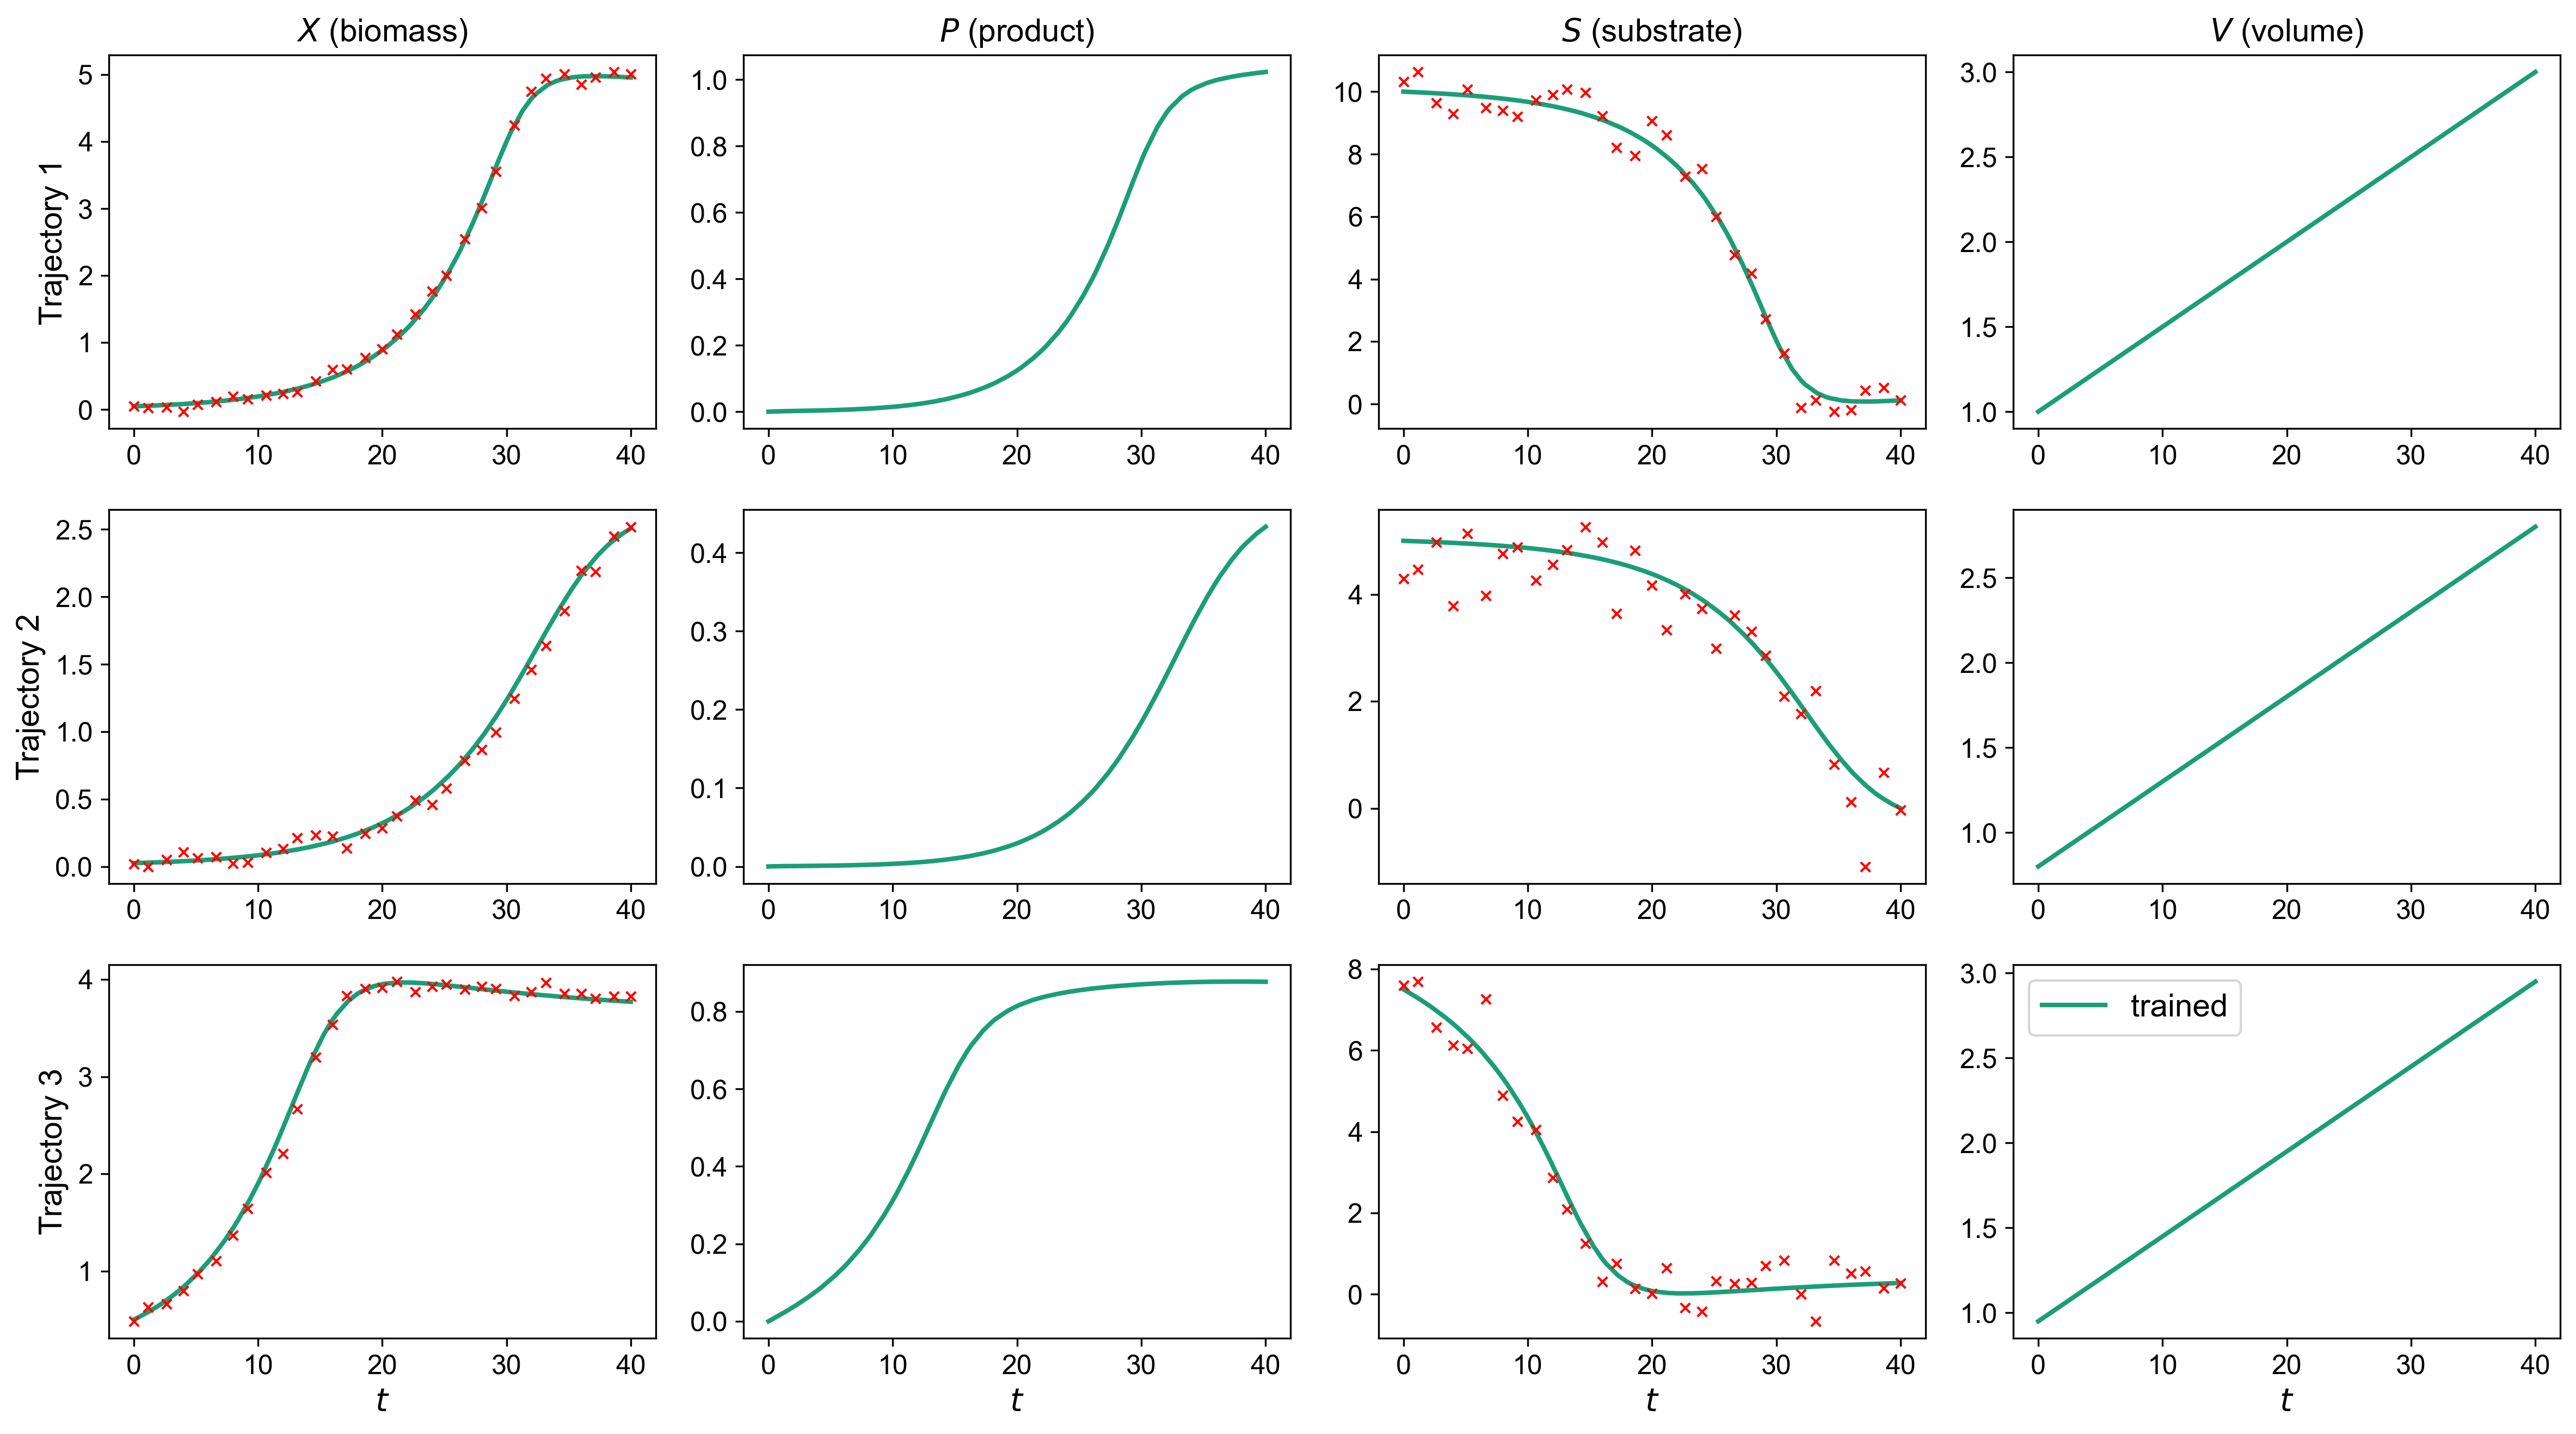

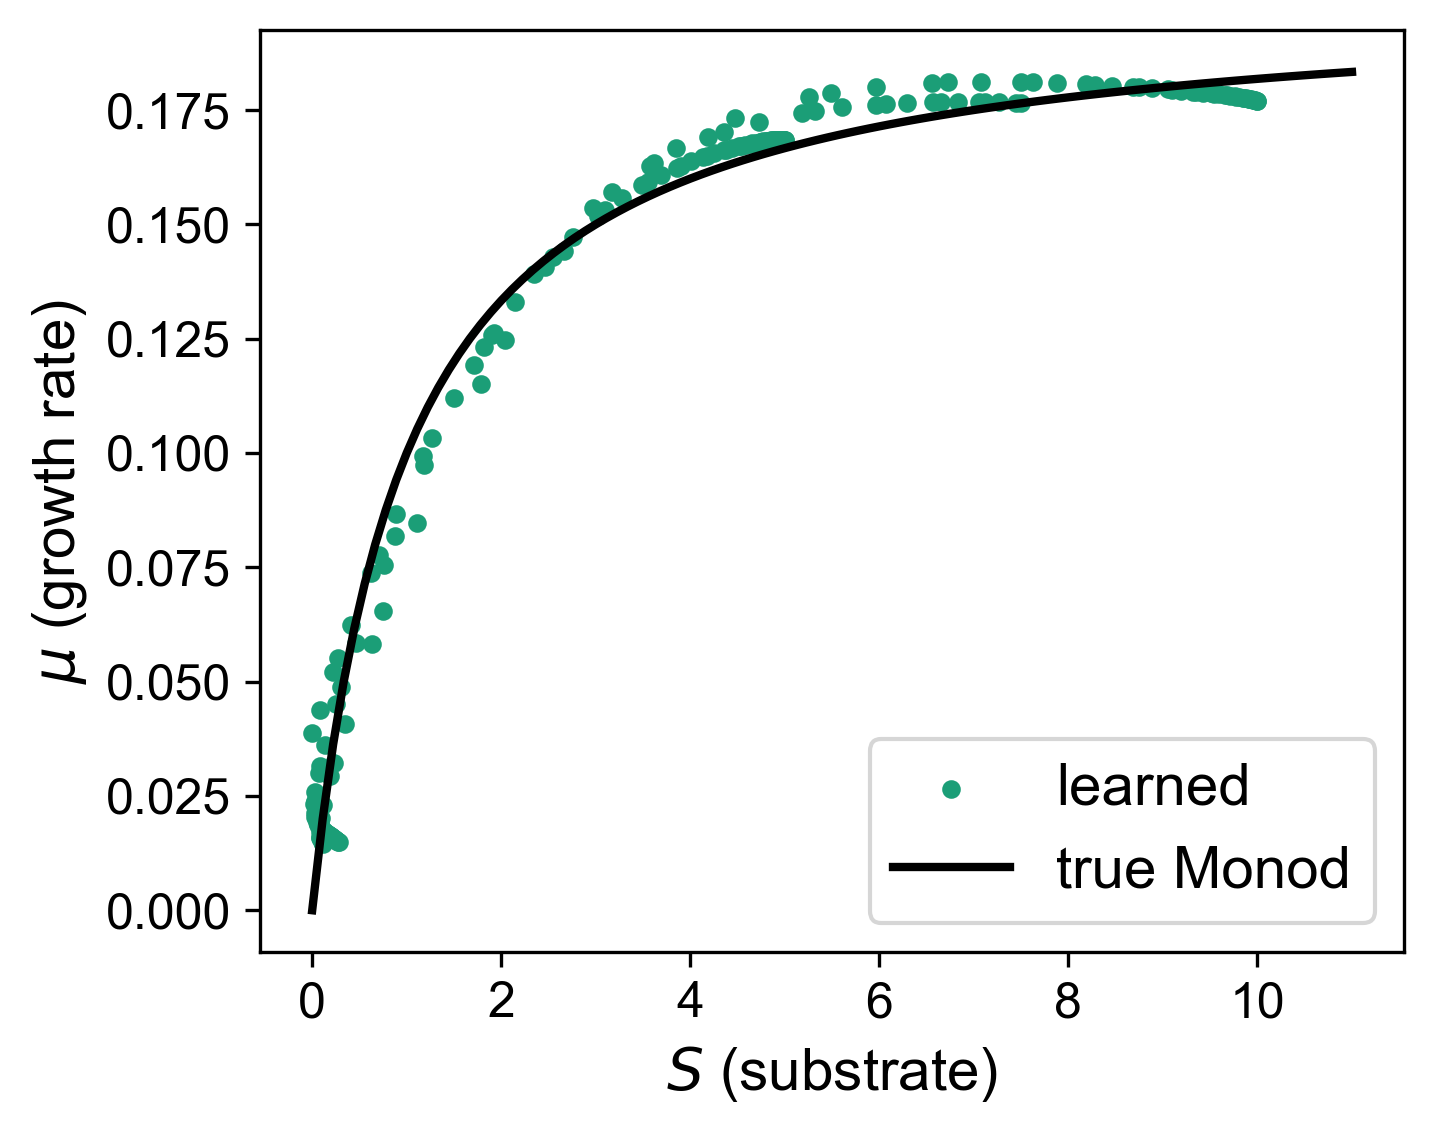

In [7]:
fig_x, _ = plot_instance_data(
    datasets=[(trained_data, 'trained', {'color': 'C0', 'ls': '-'})],
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAME,
    obs_times=problem.obs_times, obs_values=problem.obs_values,
    obs_names=MEASURED_NAMES, groups=['inputs'], legend_placement='last',
)
plt.show()

fig_mu, ax = plt.subplots(figsize=(5, 4))
for b in range(problem.num_trajectories):
    S = trained_data[b].nn_input[:, 2]
    ax.scatter(S, trained_data[b].nn_output[:, 0], s=12, color='C0',
               label='learned' if b == 0 else None)
S_grid = np.linspace(0, 11, 100)
ax.plot(S_grid, FB_PARAMS['mu_max'] * S_grid / (FB_PARAMS['Ks'] + S_grid), 'k-', label='true Monod')
ax.set_xlabel('$S$ (substrate)'); ax.set_ylabel(r'$\mu$ (growth rate)'); ax.legend()
plt.tight_layout(); plt.show()

## Step 3 - Reconstruct the unmeasured states

Product $P$ and volume $V$ were never shown to the model, yet the trained hybrid model produces a full trajectory for them. Comparing those reconstructed trajectories against the held-out columns confirms they are recovered accurately, purely from the measured channels, the mechanistic structure, and the fixed initial charge.

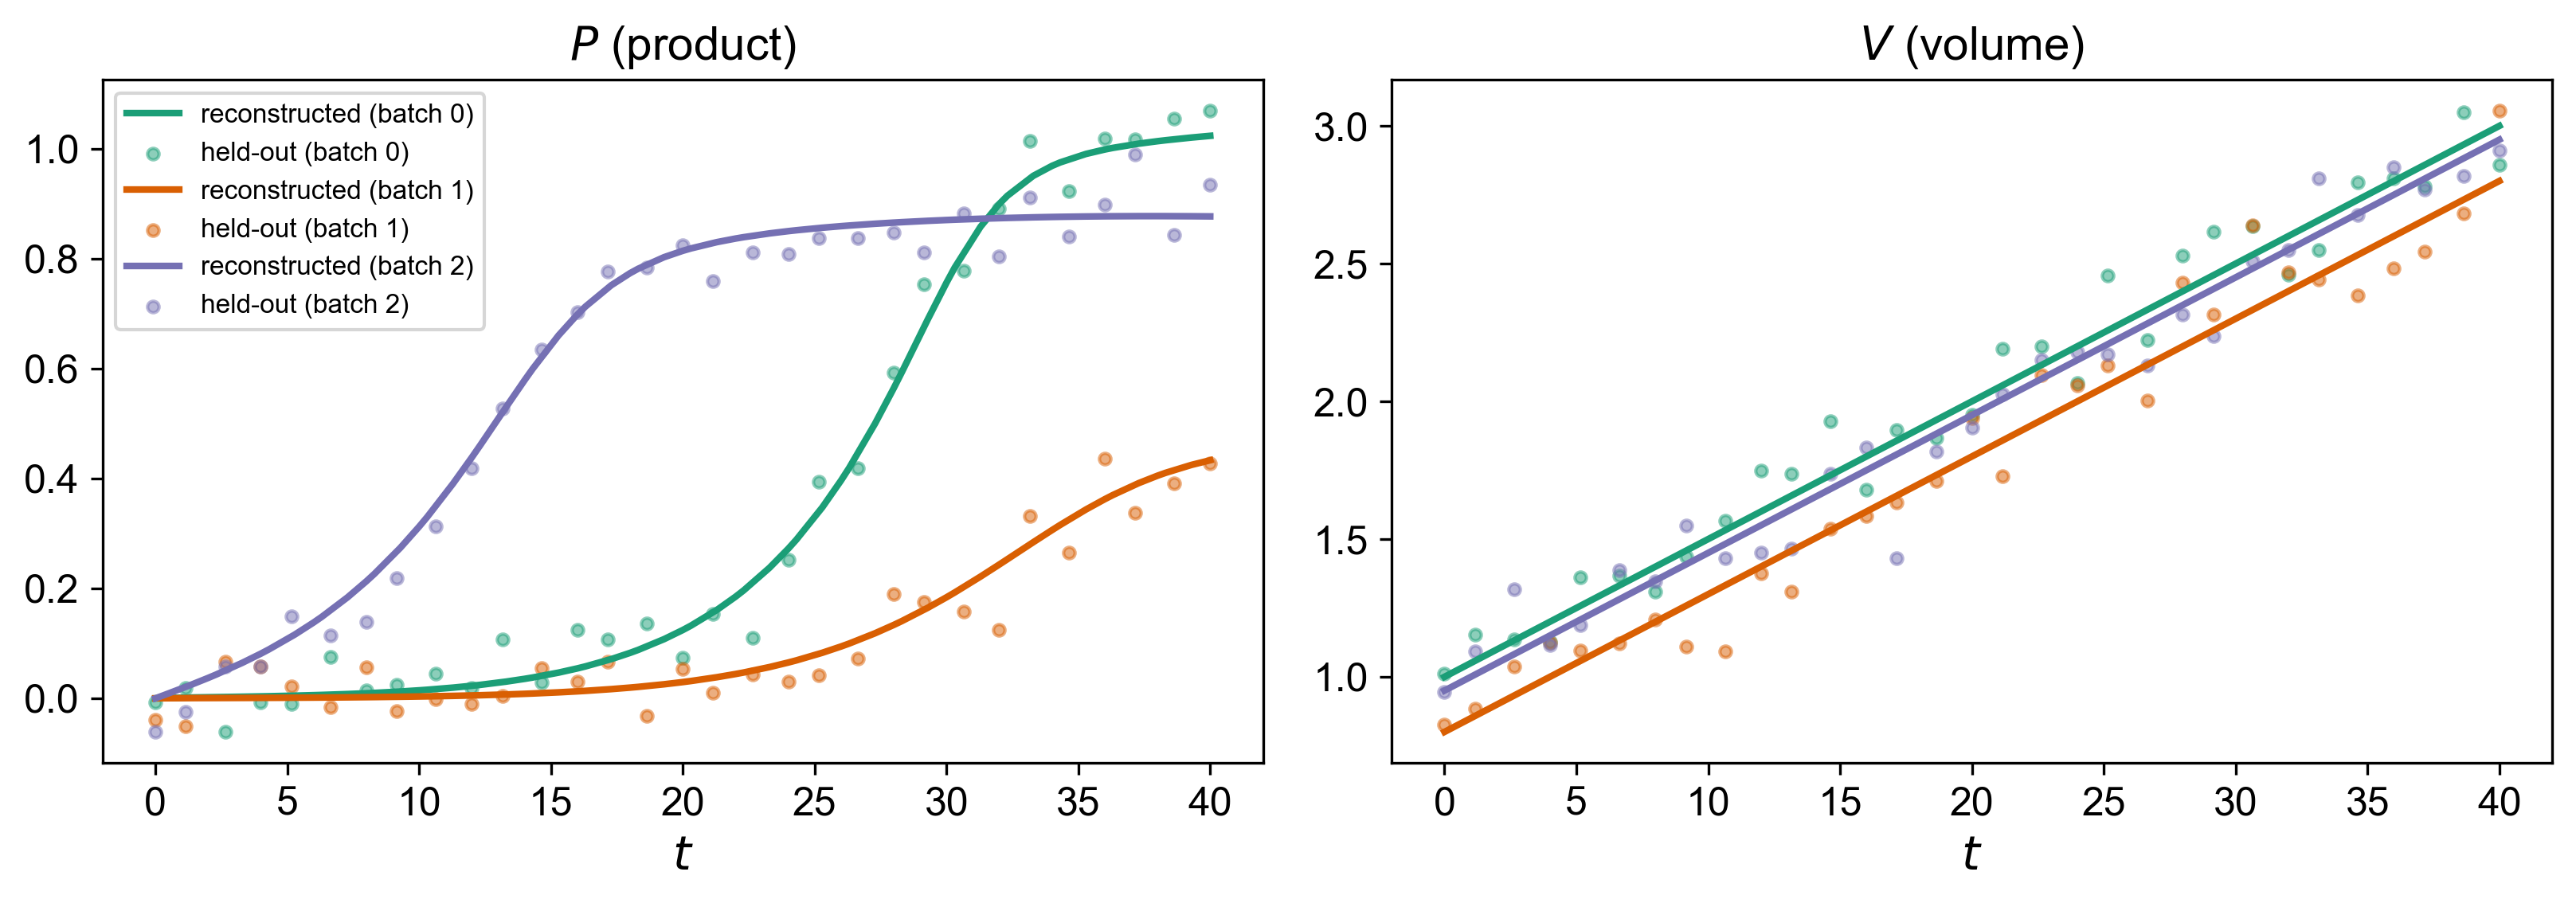

P: reconstruction RMSE vs held-out = 0.044
V: reconstruction RMSE vs held-out = 0.116


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
panels = [('$P$ (product)', 1, 'P'), ('$V$ (volume)', 3, 'V')]
for ax, (name, j, col) in zip(axes, panels):
    for b in range(problem.num_trajectories):
        t = trained_data[b].sampling_times
        ax.plot(t, trained_data[b].nn_input[:, j], color=f'C{b}',
                label=f'reconstructed (batch {b})')
        held = raw[raw['batch'] == b].sort_values('time')
        ax.scatter(held['time'], held[col], s=12, color=f'C{b}', alpha=0.5,
                   label=f'held-out (batch {b})')
    ax.set_title(name); ax.set_xlabel('$t$')
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Reconstruction error on the unmeasured states ##
for col, j in [('P', 1), ('V', 3)]:
    errs = []
    for b in range(problem.num_trajectories):
        held = raw[raw['batch'] == b].sort_values('time')
        pred = np.interp(held['time'], trained_data[b].sampling_times, trained_data[b].nn_input[:, j])
        errs.append(pred - held[col].to_numpy())
    rmse = float(np.sqrt(np.mean(np.concatenate(errs) ** 2)))
    print(f'{col}: reconstruction RMSE vs held-out = {rmse:.3f}')

## Summary

- `get_obs_vars` defines the observation model independently of the network inputs, so `obs_dim` (here 2) can be smaller than the number of states (4).
- An unmeasured state needs an anchor. Passing `unfix_io=False` keeps the known initial charge fixed, which is enough for the mechanistic dynamics to reconstruct product and volume from the measured biomass and substrate.
- The learned growth rate and the reconstructed states are both recovered accurately from a partial dataset.